In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [60]:
df = pd.read_csv('/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv')

In [61]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [62]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [63]:
df.shape

(10000, 11)

In [64]:
df.sample(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6062,718,Spain,Male,32,8,0.00,2,1,1,41399.33,0
5272,850,France,Male,47,6,0.00,1,1,0,187391.02,1
973,750,Spain,Female,38,7,97257.41,2,0,1,179883.04,0
3602,667,Spain,Male,77,2,0.00,1,1,1,34702.92,0
5379,627,France,Female,21,7,98993.02,1,1,1,169156.64,0
928,520,Germany,Male,61,8,133802.29,2,1,1,90304.01,0
1109,595,France,Male,31,4,0.00,2,1,0,189995.86,0
9078,647,Germany,Male,52,7,130013.12,1,1,1,190806.36,1
7822,581,Germany,Male,50,2,143829.20,2,1,0,181224.24,1
1222,536,France,Male,46,1,65733.41,1,1,0,61094.53,0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [68]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

# OneHotEncoding

**Multicollinearity** occurs when two or more features provide the same information, making it difficult for some machine learning models to determine the importance of each feature.Example

Ex :- Suppose we have:
Age,
Birth Year
If the current year is 2026,
Age = 2026 − Birth Year
Both features tell almost the same information

**Dummy Variable Trap** is a situation where one dummy variable(dummy means Substitute means Substitute means something that takes the place of something else.example=A substitute teacher teaches when the regular teacher is absent.Country = France France = 1 , Germany = 0 , Spain = 0 , **Substitute = Replace** ) is completely determined by the other dummy variables, causing perfect multicollinearity. It is avoided by using **drop_first=True** , which removes one redundant dummy column.

Definition se hatke samjho: **drop_first=True** karne se dummy variables ki dependency kam ho jati hai.
Agar **drop_first=True** use na karein, to har category ke liye alag dummy variable banega:

France = 100
Spain = 010
Germany = 001

Ye dummy variables ek dusre par zyada dependent hote hain. Isliye hum ek kaam karte hain **drop_first=True** use karke ek dummy variable (maan lo France) hata dete hain.

Ab sirf:

Spain = 10
Germany = 01

bachta hai, aur France automatically 00 se represent ho jata hai. Isse extra column add karne ki zarurat nahi padti, koi information loss nahi hota, aur dummy variables ke beech ki perfect dependency bhi remove ho jati hai.

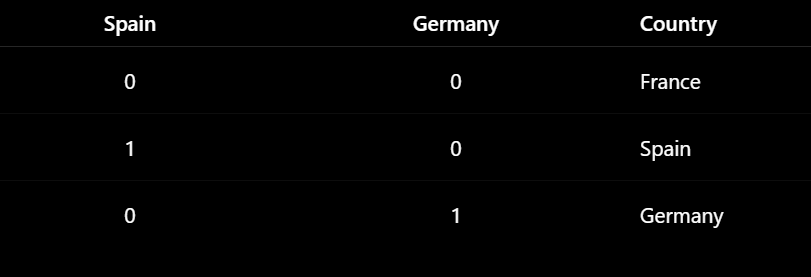

This is one hot encoding by the pandas

In [69]:
df = pd.get_dummies(df,columns=['Geography', 'Gender' ], drop_first=True,dtype='int64')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [72]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [73]:
X = df.drop(columns=['Exited'])
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [74]:
y = df['Exited']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [75]:

from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test= train_test_split(X,y,test_size=0.2, random_state=1)

In [76]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [77]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [78]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [79]:
model = Sequential()
#model.add(Dense(3,activation='sigmoid',input_dim=11)) # Dense create the layer with 3 nerouns
# and input_dim created how many input it take like 11 feature 
#Now we increase the hidden layer and add another hidden layer 
model.add(Dense(11,activation='relu',input_dim=11)) # it is better at the neral network 
model.add(Dense(11,activation='relu')) # this is another layer hidden
model.add(Dense(1,activation='sigmoid')) # output 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])# defining the loss for the model means which loss function it is using 

In [82]:
#model.fit(X_train_scaled,y_train, epochs=110,validation_split=0.2) #This is where nearal_network it training
# To plot this in the graph we do 
history = model.fit(X_train_scaled,y_train, epochs=200,validation_split=0.2) # see the last code 

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7136 - loss: 0.5666 - val_accuracy: 0.7962 - val_loss: 0.4766
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8005 - loss: 0.4542 - val_accuracy: 0.7962 - val_loss: 0.4439
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4309 - val_accuracy: 0.8069 - val_loss: 0.4253
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8195 - loss: 0.4150 - val_accuracy: 0.8175 - val_loss: 0.4086
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8313 - loss: 0.3999 - val_accuracy: 0.8300 - val_loss: 0.3934
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8383 - loss: 0.3854 - val_accuracy: 0.8381 - val_loss: 0.3783
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8445 - loss: 0.3736 - val_accuracy: 0.8462 - val_loss: 0.3676
Epoch 8/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3654 - val_accu

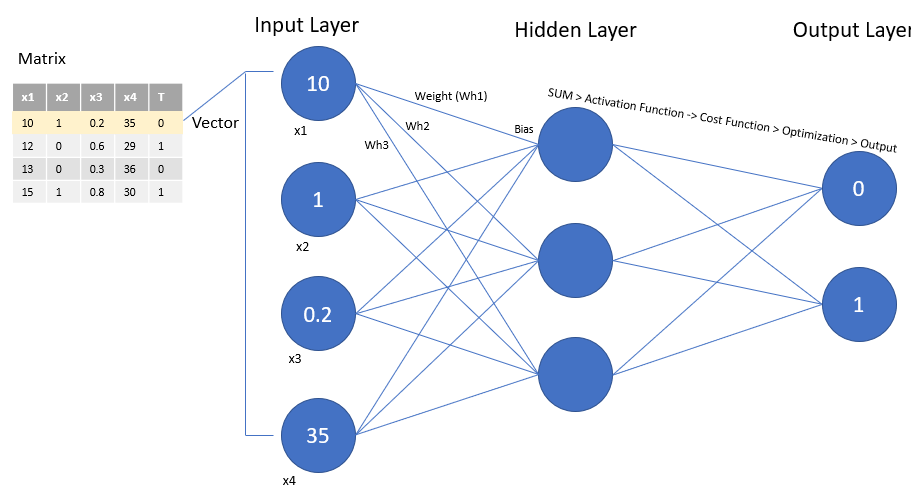
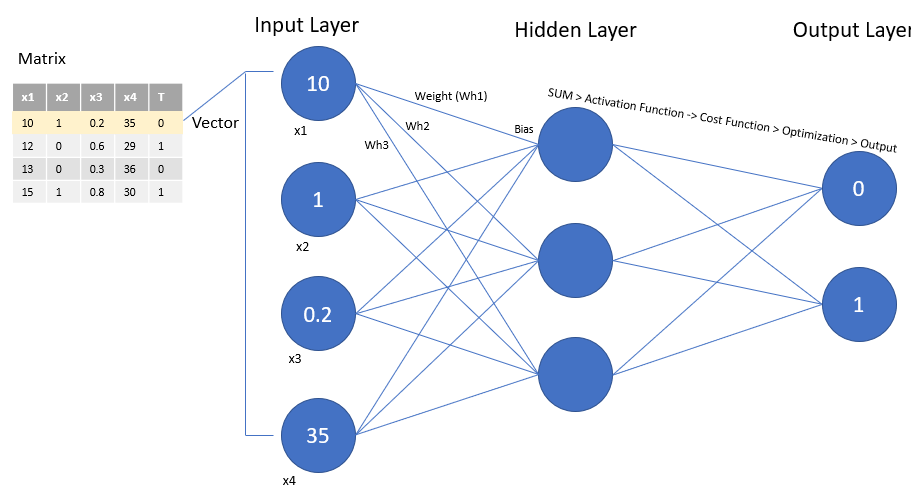

In [83]:
model.layers[0].get_weights() # This is weight and bias of the means first 3 nerons
# 33 weight and 3 bias = total 36 

[array([[ 0.01802388,  0.02397284,  0.05631725,  0.02416373,  0.11271352,
         -0.47924355, -0.09709191,  0.08805752,  0.07040315,  0.07556704,
          0.549157  ],
        [-0.4296025 , -0.25034362, -0.48580503,  0.2149102 , -0.8121969 ,
          0.7916965 , -1.0894309 ,  1.0960318 ,  0.41605258,  1.0693722 ,
         -0.43806967],
        [ 0.10892053, -0.21261238, -0.47365105,  0.01142754, -0.1489694 ,
         -0.40806553,  0.35399184,  0.08062362, -0.13704593,  0.12378452,
         -0.4359227 ],
        [ 0.24187768, -0.1042529 ,  1.4648409 ,  0.9101133 , -0.09635209,
          0.43276498,  0.17183958,  0.1917375 , -0.5344756 , -0.3711644 ,
          0.05152786],
        [ 0.05267234,  1.0948842 , -0.21720968,  1.1046398 , -0.17368437,
         -0.6128151 ,  0.22893992, -0.55158395, -0.86887574,  1.0508958 ,
         -0.32900423],
        [-0.4900385 ,  0.5554724 , -0.00933329, -0.09698679, -0.05836052,
         -0.00433131,  0.21598852, -0.24908893,  0.07311752,  0.2872401

In [84]:
# here weight and bias of layer[2] with neoron 3 weight and 1 bias  
model.layers[1].get_weights()

[array([[ 6.9312342e-02,  4.3545321e-01,  3.0578598e-01,  2.2777608e-01,
          1.6770849e-01, -2.3546320e-01, -4.4542462e-01,  2.1732011e-01,
          6.6064990e-01, -4.5210856e-01,  3.5649601e-02],
        [ 6.4906234e-01, -9.2016983e-01,  3.0244696e-01, -1.4117272e-01,
         -9.6936470e-01,  1.0033618e-01, -8.0819763e-03, -5.1364076e-01,
          2.5502530e-01,  2.4394438e-01,  4.8305672e-01],
        [-8.0216920e-01,  2.9836345e-01,  7.5649518e-01,  3.7475877e-02,
          6.3284475e-01, -4.5284197e-01,  6.3911629e-01,  4.0434107e-01,
          6.4531136e-01, -8.5961640e-02,  4.0159842e-01],
        [ 9.8840290e-01,  2.2521856e-01, -9.4006181e-01, -2.8475127e-01,
         -1.5463723e-01, -5.9785718e-01, -4.1396961e-01, -7.6607347e-02,
          4.5460736e-04,  4.8231205e-01,  3.9582327e-01],
        [-6.5440983e-01, -4.8475713e-01, -3.1609929e-01,  6.7260385e-01,
         -2.6061004e-01, -8.7277435e-02,  4.6568555e-01,  2.5539610e-01,
         -7.1374789e-02, -1.2313359e+0

In [85]:
model.predict(X_test_scaled) # here we use the sigmod so the predictin is 
# and the sigmoid give the probability not the binary value 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.02540158],
       [0.04678944],
       [0.0366681 ],
       ...,
       [0.00353243],
       [0.02608057],
       [0.3974223 ]], dtype=float32)

In [86]:
# so we us the thresehold 0.5 
y_log = model.predict(X_test_scaled)
y_pred = np.where(y_log>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [87]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8705

In [88]:
history.history # it have four thing accur__,loss__,val_accura__, val_loss__ 

{'accuracy': [0.7135937213897705,
  0.8004687428474426,
  0.8098437786102295,
  0.819531261920929,
  0.831250011920929,
  0.8382812738418579,
  0.844531238079071,
  0.8460937738418579,
  0.850781261920929,
  0.8510937690734863,
  0.8553125262260437,
  0.8534374833106995,
  0.8581249713897705,
  0.8579687476158142,
  0.8570312261581421,
  0.8587499856948853,
  0.859375,
  0.8582812547683716,
  0.8590624928474426,
  0.860156238079071,
  0.8592187762260437,
  0.8615624904632568,
  0.8610937595367432,
  0.8618749976158142,
  0.8595312237739563,
  0.8621875047683716,
  0.8621875047683716,
  0.8620312213897705,
  0.8635937571525574,
  0.8628125190734863,
  0.8626562356948853,
  0.8621875047683716,
  0.8643749952316284,
  0.8628125190734863,
  0.8620312213897705,
  0.8650000095367432,
  0.8637499809265137,
  0.8637499809265137,
  0.8635937571525574,
  0.8634374737739563,
  0.8639062643051147,
  0.8634374737739563,
  0.8659374713897705,
  0.8646875023841858,
  0.8654687404632568,
  0.866562485

In [89]:
import matplotlib.pyplot as plt 

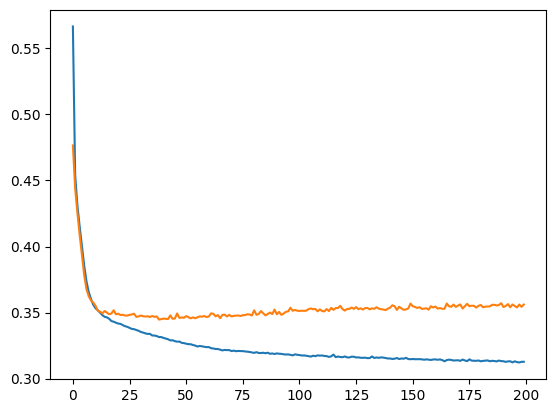

In [92]:
# ploted a graph loss vs validation loss 
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

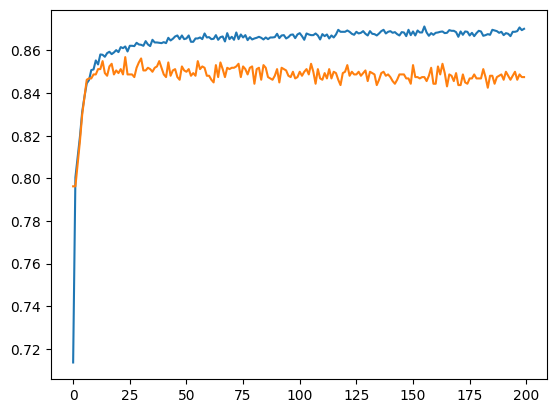

In [95]:
# Now accuracy vs validation accuacy 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])